# INSTALL LIBRARY

In [1]:
!pip install gdown

# IMPORT LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

pd.set_option('display.max_columns', None)

# DOWNLOAD DATASET DARI GOOGLE DRIVE

In [3]:
file_id = "1fhCuQppHU1D41kcB2SmKvtkP__otJWcX"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(
    url,
    "ratings_Electronics.csv",
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1fhCuQppHU1D41kcB2SmKvtkP__otJWcX
From (redirected): https://drive.google.com/uc?id=1fhCuQppHU1D41kcB2SmKvtkP__otJWcX&confirm=t&uuid=f563baf6-ea22-420a-9b67-b4045d3e87c7
To: /content/ratings_Electronics.csv
100%|██████████| 319M/319M [00:04<00:00, 70.1MB/s]


'ratings_Electronics.csv'

# LOAD DATASET

In [4]:
columns = [
    'user_id',
    'product_id',
    'rating',
    'timestamp'
]

df = pd.read_csv(
    'ratings_Electronics.csv',
    names=columns
)

# MENAMPILKAN 5 DATA PERTAMA

In [5]:
df.head()

,user_id,product_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


# MENAMPILKAN 5 DATA TERAKHIR

In [6]:
df.tail()

,user_id,product_id,rating,timestamp
7824477,A2YZI3C9MOHC0L,BT008UKTMW,5.0,1396569600
7824478,A322MDK0M89RHN,BT008UKTMW,5.0,1313366400
7824479,A1MH90R0ADMIK0,BT008UKTMW,4.0,1404172800
7824480,A10M2KEFPEQDHN,BT008UKTMW,4.0,1297555200
7824481,A2G81TMIOIDEQQ,BT008V9J9U,5.0,1312675200


# UKURAN DATASET

In [7]:
print("Jumlah baris dan kolom:")
print(df.shape)

Jumlah baris dan kolom:
(7824482, 4)


# INFORMASI DATASET

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   user_id     object 
 1   product_id  object 
 2   rating      float64
 3   timestamp   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


# CEK MISSING VALUE

In [9]:
print("Jumlah missing value tiap kolom:")
print(df.isnull().sum())

Jumlah missing value tiap kolom:
user_id       0
product_id    0
rating        0
timestamp     0
dtype: int64


# CEK DUPLICATE DATA

In [10]:
duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


# STATISTIK DESKRIPTIF

In [11]:
df.describe()

,rating,timestamp
count,7.824482e+06,7.824482e+06
mean,4.012337e+00,1.338178e+09
std,1.380910e+00,6.900426e+07
min,1.000000e+00,9.127296e+08
25%,3.000000e+00,1.315354e+09
50%,5.000000e+00,1.361059e+09
75%,5.000000e+00,1.386115e+09
max,5.000000e+00,1.406074e+09


# JUMLAH USER UNIK

In [12]:
unique_users = df['user_id'].nunique()

print(f"Jumlah user unik: {unique_users}")

Jumlah user unik: 4201696


# JUMLAH PRODUK UNIK

In [13]:
unique_products = df['product_id'].nunique()

print(f"Jumlah produk unik: {unique_products}")

Jumlah produk unik: 476002


# DISTRIBUSI RATING

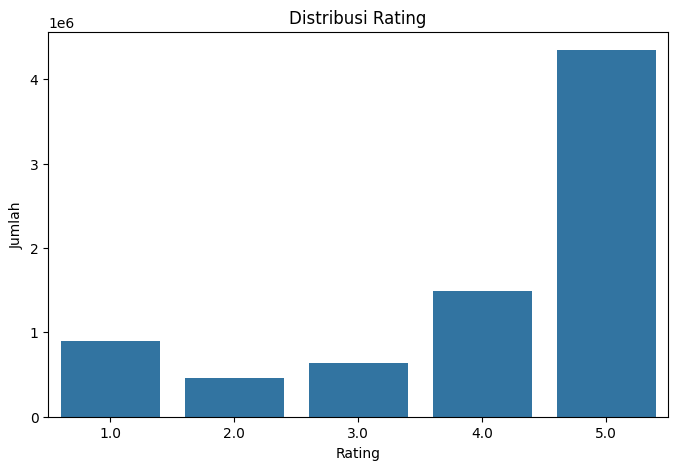

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rating',
    data=df
)

plt.title('Distribusi Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah')

plt.show()

# TOP 10 PRODUK PALING BANYAK DIREVIEW

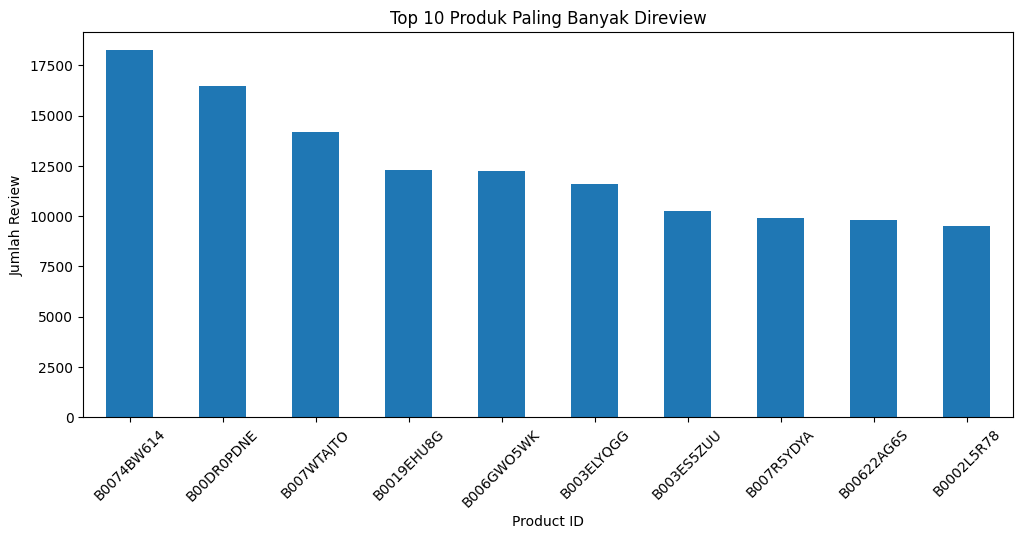

In [15]:
top_products = (
    df['product_id']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

top_products.plot(kind='bar')

plt.title('Top 10 Produk Paling Banyak Direview')
plt.xlabel('Product ID')
plt.ylabel('Jumlah Review')

plt.xticks(rotation=45)

plt.show()

# TOP 10 USER PALING AKTIF

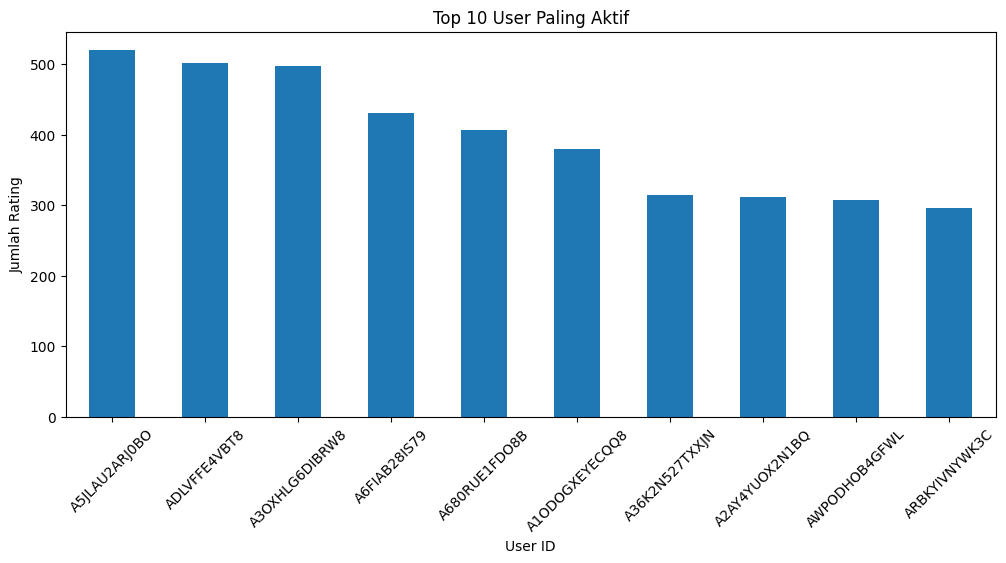

In [16]:
top_users = (
    df['user_id']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

top_users.plot(kind='bar')

plt.title('Top 10 User Paling Aktif')
plt.xlabel('User ID')
plt.ylabel('Jumlah Rating')

plt.xticks(rotation=45)

plt.show()

# CEK SPARSITY DATA

In [17]:
num_interactions = len(df)

sparsity = (
    1 -
    (
        num_interactions /
        (unique_users * unique_products)
    )
) * 100

print(f"Sparsity dataset: {sparsity:.2f}%")

Sparsity dataset: 100.00%


# MENGAMBIL SAMPLE DATA

In [18]:
user_counts = df['user_id'].value_counts()

active_users = user_counts[user_counts >= 20].index

df_active = df[df['user_id'].isin(active_users)]

print("Jumlah active users:")
print(len(active_users))

Jumlah active users:
13351


# SAMPLING DATA DARI ACTIVE USERS

In [20]:
df_sample = df_active.sample(
    n=200000,
    random_state=42
)

print("Sample dataset berhasil dibuat!")

print(df_sample.shape)

Sample dataset berhasil dibuat!
(200000, 4)


# MENYIMPAN SAMPLE DATASET

In [21]:
df_sample.to_csv(
    'sample_data.csv',
    index=False
)

# MENAMPILKAN SAMPLE DATASET

In [22]:
df_sample.head()

,user_id,product_id,rating,timestamp
1888256,A3CJGOATIQ948P,B001BYASQ0,3.0,1318550400
2793891,A1PSUH0U1FPQ6R,B002QXZPFE,4.0,1376870400
3747209,A23QSTB241NRF3,B0040HJOO2,1.0,1335225600
4240947,A1IU4JZFDZA9HJ,B004LRO7FW,5.0,1326326400
5363711,A1B2D4J8KF4DFN,B006DKEQL0,2.0,1368144000


# Kesimpulan

- Dataset memiliki struktur yang sesuai untuk collaborative filtering.
- Dataset terdiri dari user_id, product_id, rating, dan timestamp.
- Dataset berukuran besar sehingga dilakukan sampling.
- Sample dataset dibuat menggunakan active users dengan minimal 20 interaksi untuk mengurangi sparsity.
- Sample dataset akan digunakan untuk preprocessing dan modeling.